# **ΤΕΛΙΚΗ ΕΡΓΑΣΙΑ**

Φοιτητής: Ιατρού Κωνσταντίνος 58071

Καθηγητής: Θεοδωρακόπουλος Ηλίας

#**ΜΕΡΟΣ 1 - Ταξινόμηση Εικόνων**

**Στο πρώτο μέρος καλείστε να επιλύσετε ένα πρόβλημα ταξινόμησης εικόνων που προκύπτουν από αλγορίθμους ανίχνευσης προσώπων, με στόχο την επιβεβαίωση χρήσης μάσκας. Τα δεδομένα που θα χρησιμοποιήσετε βρίσκονται στο αρχείο Mask_DB.zip, και αποτελούνται από 1044 εικόνες προσώπων χωρίς τη χρήση μάσκας (without_mask), ισάριθμες εικόνες προσώπων που χρησιμοποιούν μάσκα (with_mask), και 56 εικόνες προσώπων που χρησιμοποιούν μάσκα εσφαλμένα (mask_incorrect_use).**



In [1]:
# Εισαγωγή απαραίτητψν βιβλιοθηκών, συναρτήσεων και κλάσεων
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import transforms, datasets
from torchvision.transforms import v2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc

Σε πρώτη φάση εισάγονται όλες οι βιβλιοθήκες, οι συναρτήσεις και οι κλάσεις που θα χρησιμοποιηθούν στην συνέχεια της εργασίας.

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Κάνω mount το drive καθώς εκεί ανέβασα τον φάκελο που περιέχει όλες τις εικόνες, γιατι πρόκειται για ένα σχετικά μεγάλο dataset και δεν γίνεται να το ανεβάζω ξανά και ξανά στο Google Colab για να εκτελώ την υλοποίηση της άσκησης.

# **Ερώτημα Α**

**Ως δεδομένα εκπαίδευσης, επικύρωσης και δοκιμής θα χρησιμοποιηθούν μόνο εικόνες από τις κλάσεις with_mask και without_mask με τις αντίστοιχες ετικέτες. Χωρίστε τα δεδομένα τυχαία σε 60% δεδομένα εκπαίδευσης, 20% δεδομένα επικύρωσης και 20% δεδομένα δοκιμής.**

In [3]:
# Οι εικόνες βρίσκονται στον παρακάτω φάκελο
base_dir = '/content/drive/My Drive/Final_Project_folder/Mask_DB'

# Κατηγορίες εικόνων
categories = ['without_mask', 'with_mask']

# Λίστες για την αποθήκευση των paths εικόνων και των ετικετών
image_paths = []
labels = []

# Φόρτωση εικόνων και ετικετών
for label, category in enumerate(categories):
    category_dir = os.path.join(base_dir, category)
    for image_name in os.listdir(category_dir):
        image_path = os.path.join(category_dir, image_name)
        image_paths.append(image_path)
        labels.append(label)


# Διαχωρισμός δεδομένων σε σύνολα εκπαίδευσης, επαλήθευσης και δοκιμής
train_paths, test_paths, train_labels, test_labels = train_test_split(image_paths, labels, test_size=0.4, stratify=labels)
val_paths, test_paths, val_labels, test_labels = train_test_split(test_paths, test_labels, test_size=0.5, stratify=test_labels)

Μετά από αρκετές δοκιμές κατέληξα να φορτώσω τα paths όλων των εικόνων των φακέλων 'with_mask' και 'without_mask' και να δώσω δημιουργήσω και μία λίστα όπου θα ορίσω τις ετικέτες για κάθε εικόνα, βάσει της σειράς της λίστας με τα paths των εικόνων.

Στο τέλος του κελιού χωρίζω τα paths σε train, validation και test. Η αναλογία που θέλω είναι 60/20/20 για αυτό αρχικά το χωρίζω σε 60/40 (0.6/0.4) και στην συνέχεια παίρνω το μέρος με το 40% το δεδομένων και το χωρίζω ακριβώς στην μέση (test_size=0.5).

Κατα την διάρκεια του χωρισμού χρησιμοποιώ την παράμετρο stratify=labels ώστε τα δεδομένα να χωριστούν διατηρώντας την αναλογία μεταξύ των εικόνων 'with_mask' και 'without_mask' σε όλα τα μικρότερα νέα σετ.

In [4]:
print(f' Εικόνα: {image_paths[0]}, Ετικέτα: {labels[0]}\n')
print(f' Εικόνα: {image_paths[1044]}, Ετικέτα: {labels[1044]}\n')

 Εικόνα: /content/drive/My Drive/Final_Project_folder/Mask_DB/without_mask/0146.jpg, Ετικέτα: 0

 Εικόνα: /content/drive/My Drive/Final_Project_folder/Mask_DB/with_mask/0005.jpg, Ετικέτα: 1



Εκτελώ αυτές τις δύο τυπώσεις για το πρώτο path που εισάγεται από κάθε φάκελο (γνωρίζω ότι ο καθένας έχει από 1044 εικόνες) ωστέ να επιβεβαιώσω την τιμή της ετικέτας για κάθε κλάση (with_mask, without_mask).

Οπότε οι εικόνες **χωρίς μάσκα** αντιστοιχίζονται στην ετικέτα **0** και

οι εικόνες **με μάσκα** αντιστοιχίζονται στην ετικέτα **1**.

In [5]:
# Ορισμός της κλάσης Dataset για το φόρτωμα των εικόνων
class MaskDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index])
        label = float(self.labels[index])
        if self.transform:
            image = self.transform(image)
        return image, label


# Ορισμός των μετασχηματισμών (transforms)
# Ορισμός των μετασχηματισμών για το σύνολο δεδομένων εκπαίδευσης
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Δημιουργία συνόλων δεδομένων
train_dataset = MaskDataset(train_paths, train_labels, transform=transform)
val_dataset = MaskDataset(val_paths, val_labels, transform=transform)
test_dataset = MaskDataset(test_paths, test_labels, transform=transform)

# Δημιουργία DataLoader για κάθε σύνολο δεδομένων
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Επειδή δυσκολεύτηκα να εισάγω τα δεδομένα (εικόνες) με πιο απλό τρόπο, δημιούργησα μία κλάση με όνομα dataset, η οποία κατά την δημιουργία της μέσω της συνάρτησης __init__ δέχεται, τα path των εικόνων, τα label τους και το transform μπορεί να θέλουμε να εφαρμόσουμε στις εικόνες (κατά την εισαγωγή).

Κατά την δημιουτγία του instance ενός αντικειμένου τύπου MaskDataset εκτελείται και η συνάρτηση __getitem__, ώστε το data του dataset να μην είναι το path για την εικόνα, αλλά η ίδια η εικόνα που ανοίγει μέσω της εντολής Image.open() της βιβλιοθήκης PIL που εισάγαμε στην αρχή.

Στην συνέχεια δημιουργώ 3 αντικείμενα τύπου MaskDataset που πρακτικά είναι αντικείμενα παρόμοια με αυτά της κλάσης Dataset.

Τέλος χρησιμοποιώντας τα αντικείμενα MaskDataset, ορίζω 3 αντικείμενα τύπου DataLoader, ένα για το σετ εκπαίδευσης, ένα για σετ επαλήθευσης και ένα για σετ δοκιμής.

# **Ερώτημα B**

**Υλοποιείστε και εκπαιδεύστε ένα σύστημα αναγνώρισης προτύπων χρησιμοποιώντας κατάλληλους αλγορίθμους της επιλογής σας συμβατικούς ή/και νευρωνικούς. Δικαιολογήστε το σκεπτικό σας.**

In [6]:
# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Η εντολή αυτή ελέγχει αν υπάρχει διαθέσιμος κάποια συσκευή GPU για να διαθέσει το Google Colab, αλλά παρατηρήθηκε ότι δεν έχει λειτουργήσει ούτε μία φορά κατά την διάρκεια υλοποίησης της εργασίας.

Παρ' όλα αυτά κρατήθηκε, μιας και δεν δημιουργεί κανένα πρόβλημα.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(8 * 16 * 16, 16)
        self.fc2 = nn.Linear(16, 1) # 2 Κλάσεις: with_mask, without_mask (Δυαδική ταξινόμηση)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(-1, 8 * 16 * 16)  # Flatten tensor
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

# Δημιουργία του μοντέλου
simple_model = SimpleCNN().to(device)

Εδώ ορίζεται μία κλάση τύπου SimpleCNN που ορίζει μία αρχιτεκτονική ενός απλού συνελικτικού επιπέδου με 1 συνελικτικό επίπεδο, 1 fully connected κρυφό επιπεδο και το επίπεδο εξόδου (output layer).

Το συνελικτικό επίπεδο δέχεται ως είσοδο 3 τιμές (RGB τιμές του κάθε pixel) και ορίζει 8 νευρώνες για το συνελικτικό επιπεδο με μέγεθος πυρήνα (kernel) 3x3, με stride 1 και padding 1 pixel γύρωα από την εικόνα. Στο συνελικτικό επίπεδο εφαρμόζεται συνάρτηση ενεργοποίησης ReLU και Max pooling με μέγεθος πυρήνα 2x2, stride=2, χωρίς padding.

Το κρυφό επίπεδο αποτελείται από 16 νευρώνες και έχει συνάρτηση ενεργοποίησης επίσης την ReLU.

Τέλος το επίπεδο εξόδου έχει 1 νευρώνα, με την έννοια ότι η έξοδος έχει μία τιμή. Σε αυτό το επίπεδο ορίζουμε συνάρτηση ενεργοποίησης την Sigmoid για να "κανονικοποιήσω" την τιμή μεταξύ 0 και 1.

Μετά τον ορισμό του CNN ορίζω μοντέλο με όνομα simple_model.

Αυτή αποτελεί την πρώτη-πρώτη προσέγγιση δημιουργίας μοντέλου ταξινόμησης, οπότε δεν αναμένονταν καλά αποτελέσματα απαραιτήτως.

In [8]:
lr = 0.001
criterion = nn.BCELoss()
optimizer = optim.Adam(simple_model.parameters(), lr=lr)

Ορισμός της συνάρτησης απώλειας, του βελτιστοποιητή και ρυθμού μάθησης

In [9]:
# Εκπαίδευση του μοντέλου
def train_model_constant_lr(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, val_conf_matrix_bool=False):
    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0

        for images, labels in train_loader:
            labels = labels.view(-1, 1).float()  # Αλλαγή στην μορφή των ετικετών
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()  # Λειτουργία Αξιολόγηση
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                labels = labels.view(-1, 1).float()
                outputs = model(images)
                predicted = (outputs > 0.5).float()
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        accuracy = 100 * correct / total
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {accuracy:.2f}%')

    if val_conf_matrix_bool:
      all_labels = []
      all_predictions = []
      val_loss = 0
      with torch.no_grad():
        for images, labels in val_loader:
            labels = labels.view(-1, 1).float()  # Αλλαγή στην μορφή των ετικετών
            outputs = model(images)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

      cm = confusion_matrix(all_labels, all_predictions)
      plt.figure(figsize=(8,6))
      sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
      plt.xlabel('Πρόβλεψη')
      plt.ylabel('Πραγματικές ετικέτες')
      plt.title('Confusion Matrix (Validation Set)')
      plt.show()
      print('\n')

Εδώ ορίζεται η συνάρτηση που θα εκτελεί την εκπαίδευση νευρωνικού δικτύου για σταθερή τιμή στον ρυθμό μάθησης

In [10]:
# Εκπαίδευση του μοντέλου
def train_model_lr_list(model, train_loader, val_loader, lr_list, criterion, num_epochs=10, val_conf_matrix_bool=False):
    i = 0
    lr = lr_list[0]
    optimizer =  optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()

        if (epoch+1)%5==1 and epoch!=0:
            i = i+1
            lr = lr_list[i]
            optimizer =  optim.Adam(model.parameters(), lr=lr)

        running_loss = 0.0

        for images, labels in train_loader:
            labels = labels.view(-1, 1).float()  # Αλλαγή στην μορφή των ετικετών
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()  # Λειτουργία Αξιολόγηση
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                labels = labels.view(-1, 1).float()
                outputs = model(images)
                predicted = (outputs > 0.5).float()
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        accuracy = 100 * correct / total
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {accuracy:.2f}%')


    if val_conf_matrix_bool:
      all_labels = []
      all_predictions = []
      val_loss = 0
      with torch.no_grad():
        for images, labels in val_loader:
            labels = labels.view(-1, 1).float()  # Αλλαγή στην μορφή των ετικετών
            outputs = model(images)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

      cm = confusion_matrix(all_labels, all_predictions)
      plt.figure(figsize=(8,6))
      sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
      plt.xlabel('Πρόβλεψη')
      plt.ylabel('Πραγματικές ετικέτες')
      plt.title('Confusion Matrix (Validation Set)')
      plt.show()
      print('\n')

Εδώ ορίζεται η συνάρτηση που θα εκτελεί την εκπαίδευση νευρωνικού δικτύου για μη σταθερή τιμή στον ρυθμό μάθησης. Οι τιμές του ρυθμού μάθησης θα υπάρχουν σε μία λίστα.

In [11]:
def model_evaluation(model, test_loader, criterion, precision_recall_bool=False, confusion_matrix_bool=False):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            labels = labels.view(-1, 1).float()  # Αλλαγή στην μορφή των ετικετών
            outputs = model(images)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    print(f'\nTest Loss: {test_loss:.5f}, Test Accuracy: {accuracy:.4f}%')

    # Πίνακας σύγχυσης
    if confusion_matrix_bool:
      cm = confusion_matrix(all_labels, all_predictions)
      plt.figure(figsize=(8,6))
      sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
      plt.xlabel('Πρόβλεψη')
      plt.ylabel('Πραγματικές ετικέτες')
      plt.title('Confusion Matrix (Test set)')
      plt.show()
      print('\n')

    # Καμπύλη precision-recall
    if precision_recall_bool:
      test_predictions_with_mask = []
      test_predictions_without_mask = []
      test_truth = []

      with torch.no_grad():
          for images, labels in test_loader:
              outputs = model(images)
              probabilities = torch.sigmoid(outputs)[:, 0]  # Πιθανότητες για την κλάση "with_mask"
              test_predictions_with_mask.extend(probabilities.tolist())
              test_predictions_without_mask.extend((1 - probabilities).tolist())  # Πιθανότητες για την κλάση "without_mask"
              test_truth.extend(labels.tolist())

      # Υπολογισμός καμπύλης precision-recall για την κλάση "with_mask"
      precision_with_mask, recall_with_mask, _ = precision_recall_curve(test_truth, test_predictions_with_mask, pos_label=1)
      auc_score_with_mask = auc(recall_with_mask, precision_with_mask)

      # Υπολογισμός καμπύλης precision-recall για την κλάση "without_mask"
      precision_without_mask, recall_without_mask, _ = precision_recall_curve(test_truth, test_predictions_without_mask, pos_label=0)
      auc_score_without_mask = auc(recall_without_mask, precision_without_mask)

      # Απεικόνιση καμπυλών Precision-Recall
      plt.figure(figsize=(8, 6))
      plt.plot(recall_with_mask, precision_with_mask, label=f'With Mask AUC = {auc_score_with_mask:.8f}', color='blue')
      plt.plot(recall_without_mask, precision_without_mask, label=f'Without Mask AUC = {auc_score_without_mask:.8f}', color='red')
      plt.xlabel('Recall')
      plt.ylabel('Precision')
      plt.title('Καμπύλη Precision-Recall για κάθε κλάση')
      plt.legend(loc='best')
      plt.grid(True)
      plt.ylim([0, 1.05])
      plt.show()

Ορίζεται η συνάρτηση για την εκτέλεση της αξιλόγησης του μοντέλου πάνω στο test set. Για να παραχθεί σωστά η καμπύλη για τα δεδομένα χωρίς μάσκα πρέπει να γίνει μία τροποποίηση στις πιθανότητες που παράγονται. Να αφαιρεθούν από 1. Αυτό συμβαίνει γιατί έχουμε δυαδική ταξινόμηση και όταν η τιμής της πιθανότητας είναι μεγαλυτερη του 0.5 ταξινομούνται ως "με μασκα" και όταν είναι μικρότερη του 0.5 ταξινομούνται ως "χωρίς μασκα".

Άρα υπάρχει ένα ζήτημα για την καμπύλη precison-recall για τα δεδομένα without_mask που επιλύεται αν υπολογίσουμε αντίστροφα την πιθανότητα αφαιρώντας την υπολογισμένη πιθανότητα από το 1.

Epoch [1/10], Loss: 13.5217, Val Loss: 4.5434, Val Accuracy: 53.11%
Epoch [2/10], Loss: 11.6382, Val Loss: 3.4617, Val Accuracy: 88.76%
Epoch [3/10], Loss: 7.6523, Val Loss: 2.1768, Val Accuracy: 89.47%
Epoch [4/10], Loss: 4.9085, Val Loss: 1.5147, Val Accuracy: 91.15%
Epoch [5/10], Loss: 3.5828, Val Loss: 1.2071, Val Accuracy: 93.30%
Epoch [6/10], Loss: 2.9311, Val Loss: 1.0726, Val Accuracy: 94.74%
Epoch [7/10], Loss: 2.5807, Val Loss: 0.9407, Val Accuracy: 95.22%
Epoch [8/10], Loss: 2.3200, Val Loss: 0.8795, Val Accuracy: 95.93%
Epoch [9/10], Loss: 2.1046, Val Loss: 0.8685, Val Accuracy: 96.89%
Epoch [10/10], Loss: 1.9454, Val Loss: 0.7639, Val Accuracy: 97.37%


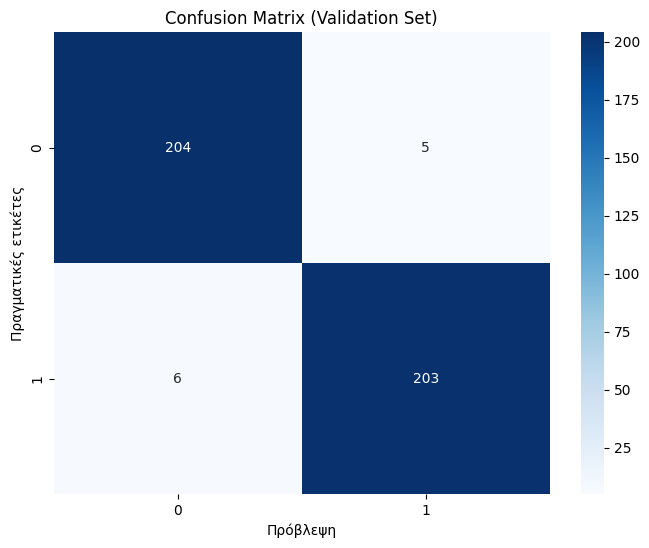

In [12]:
train_model_constant_lr(simple_model, train_loader, val_loader, criterion, optimizer, 10, True)

Εκτελείται η εκπαίδευση του μοντέλου.


Test Loss: 0.62287, Test Accuracy: 96.6507%


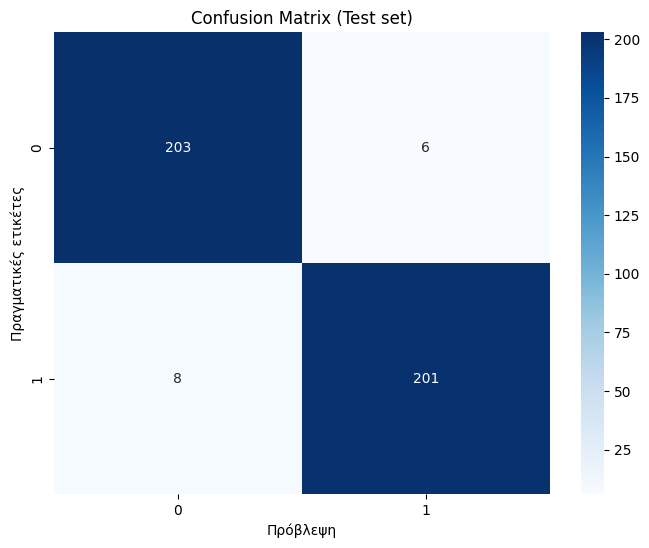

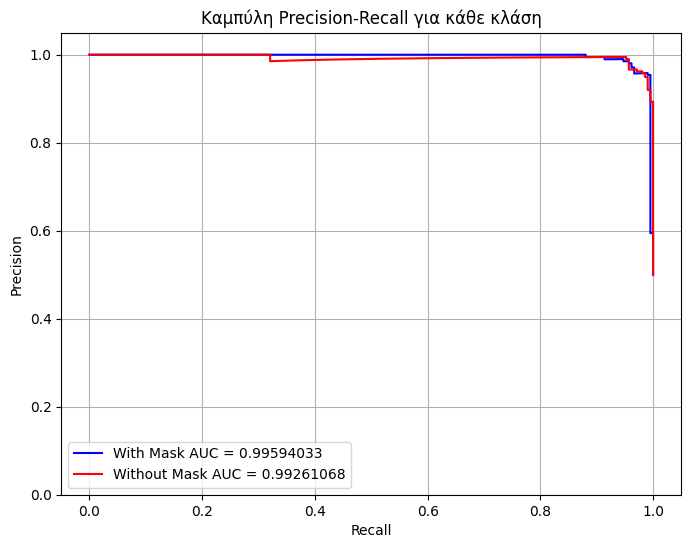

In [13]:
model_evaluation(simple_model, test_loader, criterion, True, True)

Γίνεται η αξιολόγηση του μοντέλου υπολογίζοντας την ακρίβεια πάνω στο τεστ σετ και τυπώνοντας τον πίνακα σύγχυσης και την καμπύλη Precision-Recall.

#**Ερώτημα C**

**Καθορίστε τις βέλτιστες παραμέτρους του μοντέλου σας (πχ. αριθμό ελάττωσης διαστάσεων, παραμέτρους ταξινομητών, μοντέλα δικτύων κλπ) χρησιμοποιώντας το σύνολο επικύρωσης. Δώστε μερικά παραδείγματα παραλλαγών που δοκιμάσατε και την επίδοσή τους στο validation set. Για το καλύτερο μοντέλο σας υπολογίστε το σφάλμα ταξινόμησης στο σύνολο δοκιμής, καθώς και τις καμπύλες precision-recall και το AUC.**

Σε αυτό το ερώτημα θα γίνει προσπάθεια βελτιστοποίησης του μοντέλου ώστε να βελτιωθεί η συμπεριφορά του. Οι αλλαγές που θα γίνουν αφορούν:



*   Ρυθμό Μάθησης
*   Αρχιτεκτονική Δικτύου
*   Προεπεξεργασία δεδομένων εκπαίδευσης



In [14]:
class ModifiedSimpleCNN(nn.Module):
    def __init__(self):
        super(ModifiedSimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(32 * 16 * 16, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = x.view(-1, 32 * 16 * 16)  # Flatten tensor
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

Ορίζεται νέα αρχιτεκτονική για το νευρωνικό δίκτυο στην οποία αυξάνονται οι νευρώνες του συνελικτικού επιπέδου και εφαρμόζεται batch normalization.

In [15]:
modified_simple_model = ModifiedSimpleCNN().to(device)

# Ορισμός της συνάρτησης απώλειας, του βελτιστοποιητή και ρυθμού μάθησης
learning_rate_list = [0.0001, 0.00001]
lr=learning_rate_list[0]
criterion = nn.BCELoss()
optimizer = optim.Adam(modified_simple_model.parameters(), lr=lr)

Ορισμός παραμέτρων με μοναδική αλλαγή τον ρυθμό μάθησης που θα έχει μεταβαλλόμενη τιμή.

Epoch [1/10], Loss: 7.1995, Val Loss: 3.1075, Val Accuracy: 95.45%
Epoch [2/10], Loss: 3.3254, Val Loss: 1.4569, Val Accuracy: 95.93%
Epoch [3/10], Loss: 2.5356, Val Loss: 0.9783, Val Accuracy: 96.17%
Epoch [4/10], Loss: 1.9384, Val Loss: 0.8666, Val Accuracy: 97.13%
Epoch [5/10], Loss: 1.7956, Val Loss: 0.8353, Val Accuracy: 97.37%
Epoch [6/10], Loss: 1.5630, Val Loss: 0.7265, Val Accuracy: 97.37%
Epoch [7/10], Loss: 1.5093, Val Loss: 0.8017, Val Accuracy: 97.13%
Epoch [8/10], Loss: 1.4293, Val Loss: 0.6852, Val Accuracy: 97.37%
Epoch [9/10], Loss: 1.4212, Val Loss: 0.7262, Val Accuracy: 97.37%
Epoch [10/10], Loss: 1.4117, Val Loss: 0.6564, Val Accuracy: 97.13%


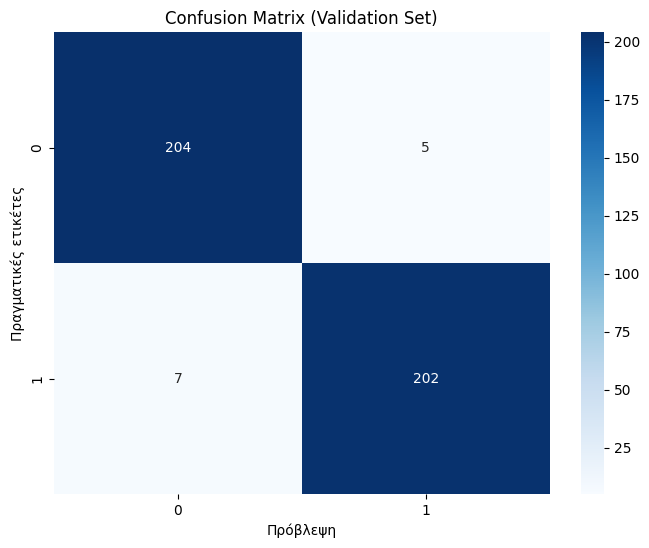

In [16]:
train_model_lr_list(modified_simple_model, train_loader, val_loader, learning_rate_list, criterion, 10, True)


Test Loss: 0.55113, Test Accuracy: 97.3684%


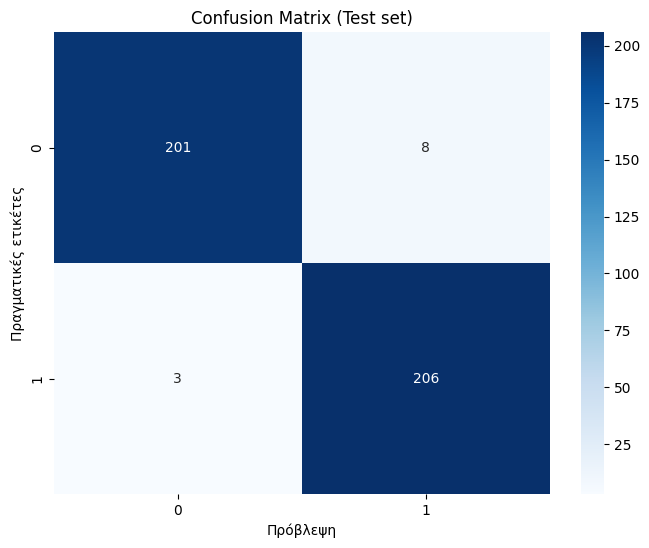

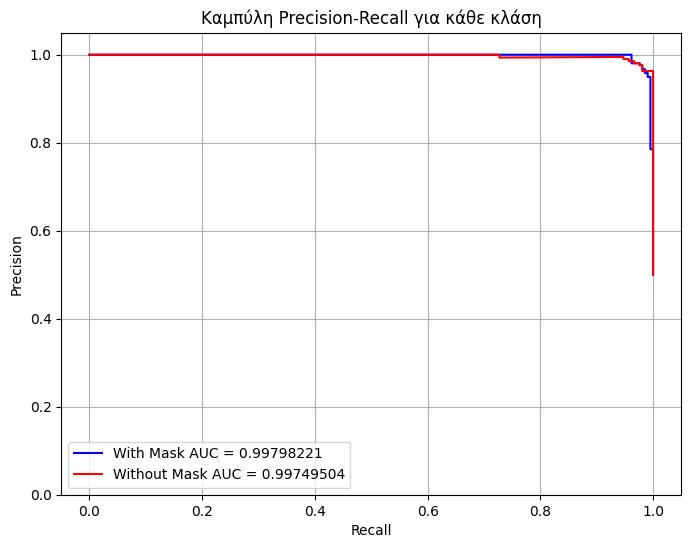

In [17]:
model_evaluation(modified_simple_model, test_loader, criterion, True, True)

In [18]:
class Complex_LayerCNN(nn.Module):
    def __init__(self):
        super(Complex_LayerCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 8 * 8)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        x = torch.sigmoid(self.fc3(x))
        return x

Μετά από αρκετές δοκιμές για πιο περίπλοκο δίκτυο που να βελτιώνει σε γενικές γραμμές την απόδοση του κάθε νέου μοντέλου, κατέληξα στην παραπάνω αρχιτεκτονική.

Epoch [1/10], Loss: 7.9288, Val Loss: 4.4738, Val Accuracy: 52.63%
Epoch [2/10], Loss: 2.9494, Val Loss: 2.0351, Val Accuracy: 86.36%
Epoch [3/10], Loss: 2.3487, Val Loss: 0.8429, Val Accuracy: 96.41%
Epoch [4/10], Loss: 1.7451, Val Loss: 0.6896, Val Accuracy: 96.89%
Epoch [5/10], Loss: 1.4430, Val Loss: 0.5569, Val Accuracy: 96.65%
Epoch [6/10], Loss: 1.1537, Val Loss: 0.5677, Val Accuracy: 97.13%
Epoch [7/10], Loss: 1.0863, Val Loss: 0.5967, Val Accuracy: 97.13%
Epoch [8/10], Loss: 1.1999, Val Loss: 0.5795, Val Accuracy: 97.13%
Epoch [9/10], Loss: 1.1014, Val Loss: 0.6160, Val Accuracy: 97.13%
Epoch [10/10], Loss: 1.1343, Val Loss: 0.5924, Val Accuracy: 97.13%


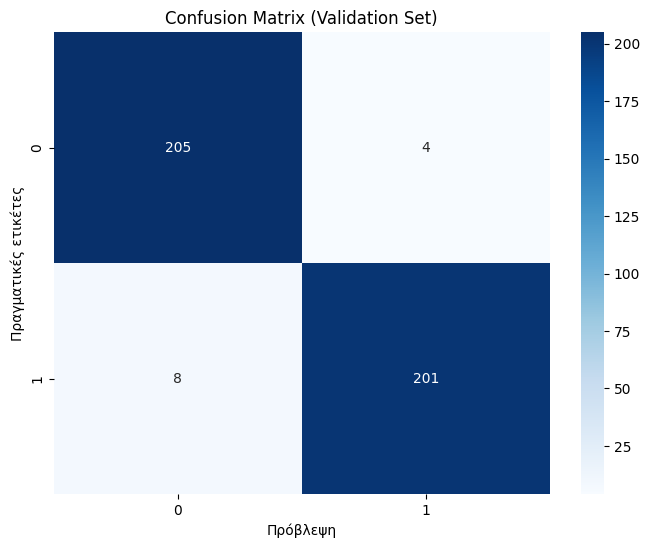

In [19]:
complex_model = Complex_LayerCNN().to(device)

# Ορισμός της συνάρτησης απώλειας, του βελτιστοποιητή και ρυθμού μάθησης
learning_rate_list = [0.0001, 0.00001]
lr=learning_rate_list[0]
criterion = nn.BCELoss()
optimizer = optim.Adam(complex_model.parameters(), lr=lr)

train_model_lr_list(complex_model, train_loader, val_loader, learning_rate_list, criterion, 10, True)


Test Loss: 0.37310, Test Accuracy: 97.8469%


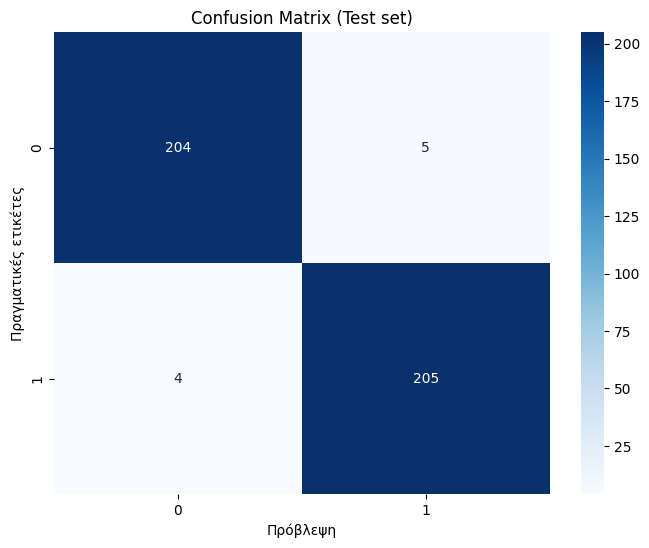

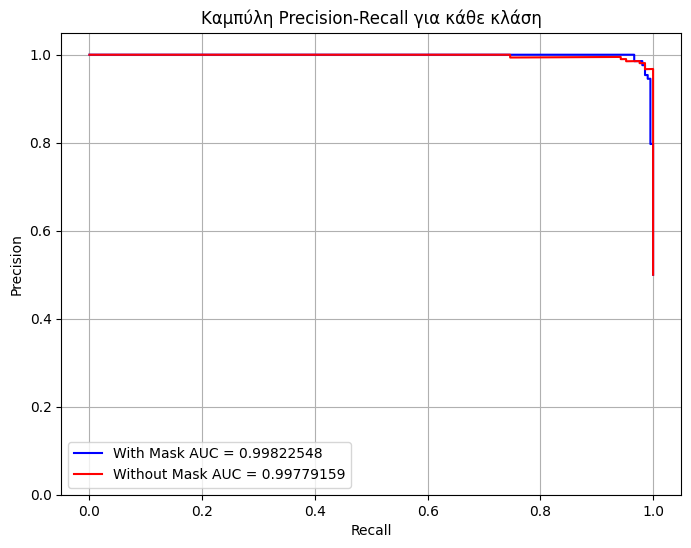

In [20]:
model_evaluation(complex_model, test_loader, criterion, True, True)

In [21]:
augmented_transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(40),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

train_augmented_dataset= MaskDataset(train_paths, train_labels, transform=augmented_transform)
full_train_dataset = ConcatDataset([train_dataset, train_augmented_dataset])

full_train_loader = DataLoader(full_train_dataset, batch_size=64, shuffle=True)

Ένας τρόπος για την βελτίωση του μοντέλου περαιτέρω, είναι εφαρμόσουμε επαύξηση στα δεδομένα εκπαίδευσης. Με αυτό τον τρόπο αυξάνεται ο αριθμός των δεδομένων εκαπίδευσης, καθώς για την εκπαίδευση θα εφαρμόσουμε στο μοντέλο τόσο τα κανονικά δεδομένα όσο και τα τροποποιημένα (αλλαγές στην φωτεινότητα, την αντίθεση, τον κορεσμό, την περιστροφή και τυχαίο καθρεφτισμό σε μερικά από αυτά).

Περιμένουμε με αυτόν τον τρόπο το μοντέλο να βελτιωθεί όντας λιγότερο ευαίσθητο σε νέα δεδομένα. Στην ουσία περιμένουμε από το μοντέλο να έχει στο τέλος καλύτερη γενίκευση.

Epoch [1/15], Loss: 9.3944, Val Loss: 5.1508, Val Accuracy: 73.21%
Epoch [2/15], Loss: 7.0520, Val Loss: 0.5443, Val Accuracy: 97.61%
Epoch [3/15], Loss: 3.6948, Val Loss: 0.4576, Val Accuracy: 97.61%
Epoch [4/15], Loss: 2.8565, Val Loss: 0.6656, Val Accuracy: 97.37%
Epoch [5/15], Loss: 2.3228, Val Loss: 0.5404, Val Accuracy: 96.89%
Epoch [6/15], Loss: 2.5048, Val Loss: 0.2880, Val Accuracy: 98.56%
Epoch [7/15], Loss: 1.7142, Val Loss: 0.2293, Val Accuracy: 98.80%
Epoch [8/15], Loss: 1.4572, Val Loss: 0.4378, Val Accuracy: 97.85%
Epoch [9/15], Loss: 1.8388, Val Loss: 0.2932, Val Accuracy: 98.56%
Epoch [10/15], Loss: 1.7647, Val Loss: 0.2687, Val Accuracy: 98.33%
Epoch [11/15], Loss: 0.8030, Val Loss: 0.2256, Val Accuracy: 98.80%
Epoch [12/15], Loss: 0.9039, Val Loss: 0.1711, Val Accuracy: 99.28%
Epoch [13/15], Loss: 0.9101, Val Loss: 0.1441, Val Accuracy: 99.28%
Epoch [14/15], Loss: 0.9006, Val Loss: 0.1453, Val Accuracy: 99.28%
Epoch [15/15], Loss: 0.8382, Val Loss: 0.1530, Val Accura

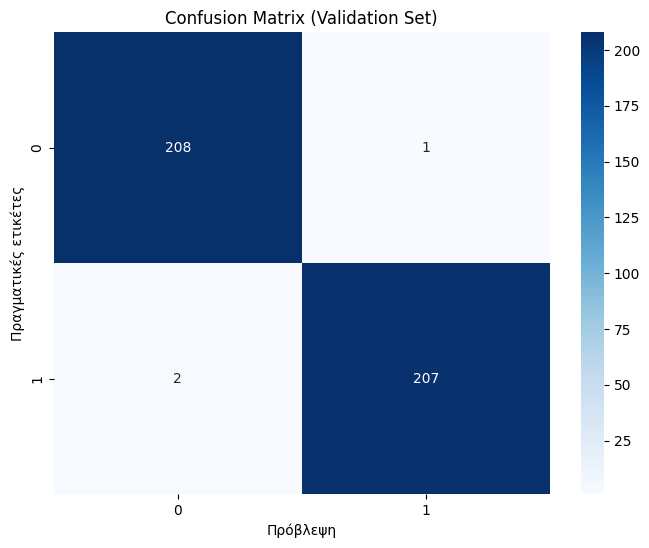

In [22]:
complex_model_augm = Complex_LayerCNN().to(device)

# Ορισμός της συνάρτησης απώλειας, του βελτιστοποιητή και ρυθμού μάθησης
learning_rate_list = [0.001, 0.0005, 0.0001]
lr=learning_rate_list[0]
criterion = nn.BCELoss()
optimizer = optim.Adam(complex_model_augm.parameters(), lr=lr)

train_model_lr_list(complex_model_augm, full_train_loader, val_loader, learning_rate_list, criterion, 15, True)

Εκτελούμε εκ νέου εκπαίδευση σε μοντέλο με την αρχιτεκτονική Complex_LayerCNN, αλλά αυτή την φορά με το νέο σετ εκπαιδευσης που περιέχει τα δεδομένα όπως είναι, αλλά και μία επεξεργασμένη εκδοχή τους.


Test Loss: 0.31654, Test Accuracy: 98.5646%


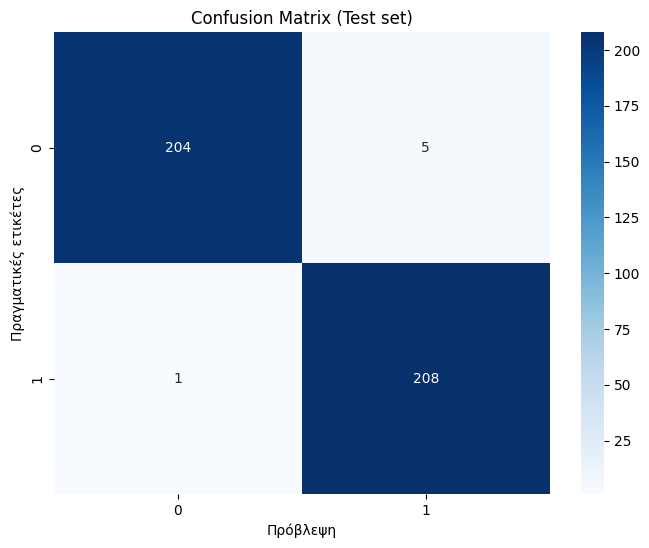

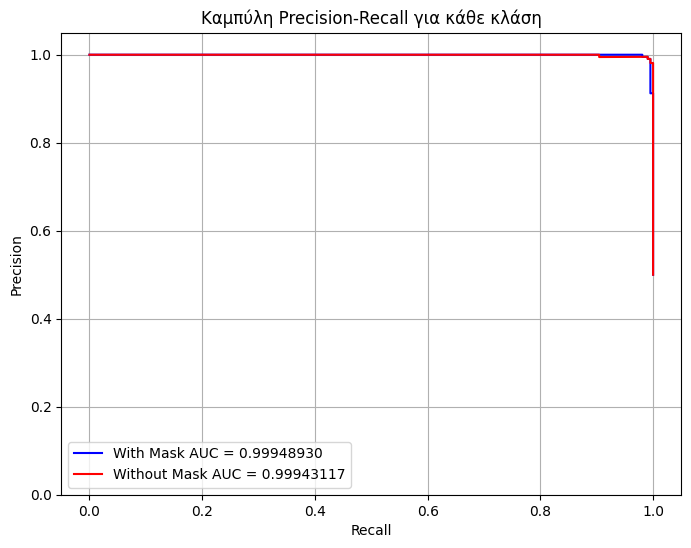

In [23]:
model_evaluation(complex_model_augm, test_loader, criterion, True, True)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 102MB/s]


Epoch [1/8], Loss: 16.8105, Val Loss: 1.2599, Val Accuracy: 92.34%
Epoch [2/8], Loss: 4.9261, Val Loss: 0.7802, Val Accuracy: 97.85%
Epoch [3/8], Loss: 2.8365, Val Loss: 0.5850, Val Accuracy: 97.61%
Epoch [4/8], Loss: 1.9252, Val Loss: 0.5298, Val Accuracy: 97.85%
Epoch [5/8], Loss: 2.2323, Val Loss: 0.5245, Val Accuracy: 98.33%
Epoch [6/8], Loss: 1.1184, Val Loss: 0.6245, Val Accuracy: 97.85%
Epoch [7/8], Loss: 1.1116, Val Loss: 0.4135, Val Accuracy: 98.09%
Epoch [8/8], Loss: 0.7481, Val Loss: 0.3988, Val Accuracy: 98.09%


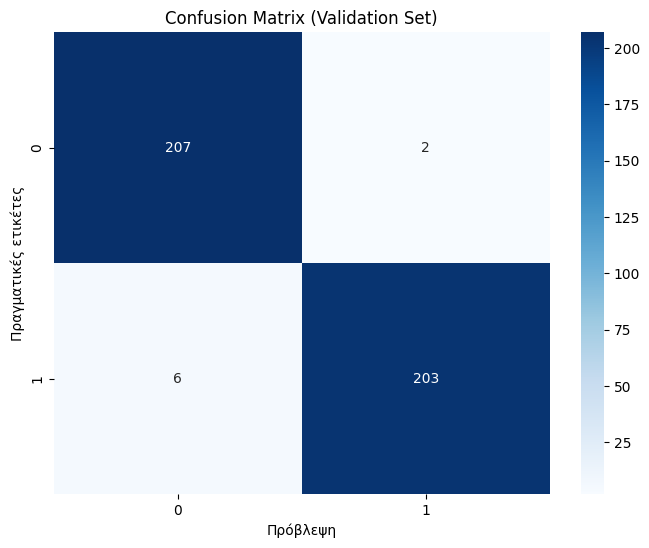




Test Loss: 0.35023, Test Accuracy: 99.0431%


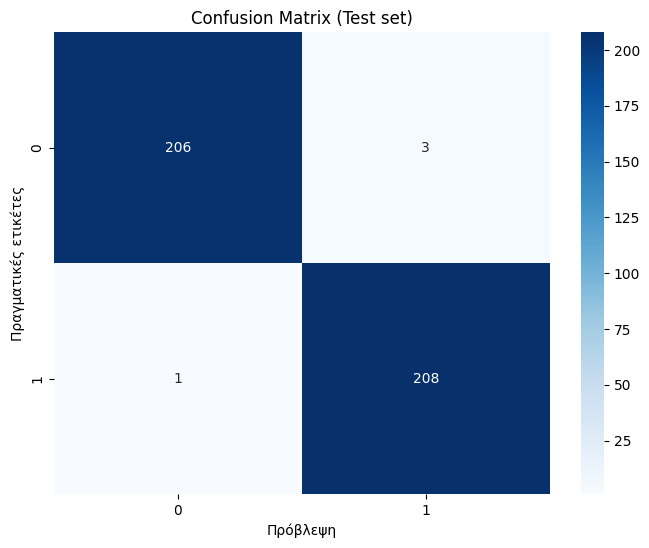

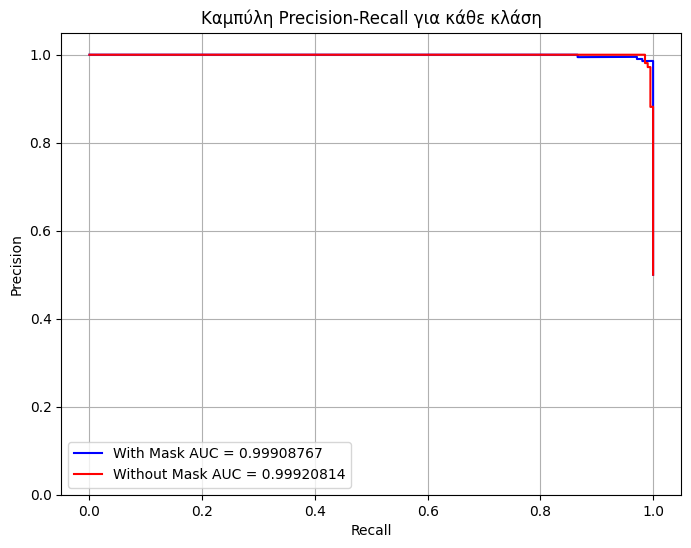

In [24]:
# Φόρτωση προεκπαιδευμένου ResNet-18
resnet18 = models.resnet18(pretrained=True)

# Αλλαγή του τελευταίου γραμμικού επιπέδου για να ταιριάζει με τον αριθμό των κλάσεων
num_of_classes = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_of_classes, 1)

resnet18 = resnet18.to(device)

# Ορισμός της συνάρτησης απώλειας και του βελτιστοποιητή
lr=0.00005
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet18.parameters(), lr=lr)

# Εκτέλεση της εκπαίδευσης
train_model_constant_lr(resnet18, full_train_loader, val_loader, criterion, optimizer, 8, True)

model_evaluation(resnet18, test_loader, criterion, True, True)

Δοκιμάστηκε η χρήση ενός προεκπαιδευμένου μοντέλου, εφαρμόζωντας του τα νέα δεδομένα εκπαίδευσης.

Το προεκπαιδευμένο μοντέλο (resnet18) εκπαιδεύτηκε για λίγες εποχές στα επαυξημένα δεδομένα εκαπίδευσης και αξιολογήθηκε όπως όλα τα προηγούμενα μοντέλα.

# **Ερώτημα D**

**Εφαρμόστε το εκπαιδευμένο μοντέλο σας στις εικόνες της κλάσης «mask_incorrect_use» και υπολογίστε το ποσοστό αυτών που ταξινομούνται εσφαλμένα ως αποδεκτή χρήση μάσκας. Προτείνετε τρόπους που μπορεί να αυξηθεί ο αριθμός των εικόνων της κλάσης mask_incorrect_use που ταξινομούνται ως μη χρήση μάσκας, χωρίς να επηρεαστούν σημαντικά τα αποτελέσματα του test set, χρησιμοποιώντας μόνο τα υπάρχοντα δεδομένα. Δοκιμάστε κάτι από αυτά που προτείνατε και δείξτε εάν έχει το επιθυμητό αποτέλεσμα.**

Το ερώτημα θα λυθεί για το μοντέλο complex_model_augm και όχι για το resnet18, παρόλο που έχει καλύτερη συμπεριφορά, καθώς για ακαδημαϊκούς λόγους προτίμησα να εργαστώ στο μοντέλο που είναι συνελικτικό νευρωνικό δίκτυο με αρχιτεκτονική δικής μου επιλογής.

Από πάνω μπορούμε να δούμε την αξιολόγηση του μοντέλου και την ακρίβεια τόσο πάνω στα δεδομένα του σετ επικύρωσης, όσο και στα δεδομένα του σετ δοκιμής.

In [25]:
# Φόρτωση εικόνων από την κλάση 'mask_incorrect_use'
incorrect_mask_paths = [os.path.join(base_dir, 'mask_incorrect_use', img) for img in os.listdir(os.path.join(base_dir, 'mask_incorrect_use'))]
incorrect_mask_labels = [0] * len(incorrect_mask_paths)

# Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=transform)
incorrect_mask_loader = DataLoader(incorrect_mask_dataset, batch_size=64, shuffle=False)

In [26]:
# Εφαρμογή του μοντέλου στις εικόνες της "mask_incorrect_use"
complex_model_augm.eval()
correctly_classified_as_without_mask = 0
total_incorrect_mask_use = len(incorrect_mask_loader.dataset)

with torch.no_grad():
    for images, _ in incorrect_mask_loader:
        outputs = complex_model_augm(images)
        predicted = (outputs > 0.5).float()
        correctly_classified_as_without_mask += (predicted == 0).sum().item()

accuracy_incorrect_use_as_without_mask = 100 * correctly_classified_as_without_mask / total_incorrect_mask_use
print(f'Ποσοστο των δεδομένων της "mask_incorrect_use" που ταξινομούνται (ορθά) ως "without_mask": {accuracy_incorrect_use_as_without_mask:.4f}%')

Ποσοστο των δεδομένων της "mask_incorrect_use" που ταξινομούνται (ορθά) ως "without_mask": 14.2857%


Γίνεται αξιολόγηση του δικτύου πάνω στα δεδομένα του σετ "incorrect_mask_use" ελέγχοντας με τι ποσοστό επιτυχίας κατηγοριοποιούνται ως "without_mask" που είναι και η επιθυμητή ταξινόμηση.

# Βελτίωση μόνο για τα δεδομένα του σετ "mask_incorrect_use"

In [27]:
augmentation_transforms = transforms.Compose([
    transforms.ColorJitter(brightness=0.5, contrast=0.5),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
])

Σαν πρώτη σκέψη δοκίμασα να εφαρμόζω τροποποιήσεις στα δεδομένα πριν τα εισάγω στο μοντέλο για ταξινόμηση.

In [28]:
mean_acc_values = []

for vv in range(100):

  # Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
  incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=augmentation_transforms)
  incorrect_mask_loader = DataLoader(incorrect_mask_dataset, batch_size=64, shuffle=False)

  # Αξιολόγηση του μοντέλου στο συνδυασμένο test set
  complex_model_augm.eval()  # Αξιολόγηση mode
  test_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in incorrect_mask_loader:
          labels = labels.view(-1, 1).float()  # Αλλάξτε τη μορφή των ετικετών
          outputs = complex_model_augm(images)
          predicted = (outputs > 0.5).float()
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
          loss = criterion(outputs, labels)
          test_loss += loss.item()

  accuracy = 100 * correct / total
  print(f'{vv}) Incorrect Mask Use Loss: {test_loss:.5f}, Incorrect Mask Use Accuracy: {accuracy:.4f}%')

  mean_acc_values.append(accuracy)

print(f'\nΜέση ακρίβεια {np.mean(mean_acc_values)}%')

0) Incorrect Mask Use Loss: 1.16066, Incorrect Mask Use Accuracy: 26.7857%
1) Incorrect Mask Use Loss: 1.19002, Incorrect Mask Use Accuracy: 16.0714%
2) Incorrect Mask Use Loss: 1.19900, Incorrect Mask Use Accuracy: 17.8571%
3) Incorrect Mask Use Loss: 1.15063, Incorrect Mask Use Accuracy: 25.0000%
4) Incorrect Mask Use Loss: 1.18529, Incorrect Mask Use Accuracy: 21.4286%
5) Incorrect Mask Use Loss: 1.18863, Incorrect Mask Use Accuracy: 19.6429%
6) Incorrect Mask Use Loss: 1.20761, Incorrect Mask Use Accuracy: 17.8571%
7) Incorrect Mask Use Loss: 1.19844, Incorrect Mask Use Accuracy: 14.2857%
8) Incorrect Mask Use Loss: 1.19273, Incorrect Mask Use Accuracy: 16.0714%
9) Incorrect Mask Use Loss: 1.20162, Incorrect Mask Use Accuracy: 16.0714%
10) Incorrect Mask Use Loss: 1.17522, Incorrect Mask Use Accuracy: 23.2143%
11) Incorrect Mask Use Loss: 1.20267, Incorrect Mask Use Accuracy: 16.0714%
12) Incorrect Mask Use Loss: 1.17426, Incorrect Mask Use Accuracy: 19.6429%
13) Incorrect Mask Use

Επαναληπτική εκτέλεση για να δούμε την συμπερυφορά του μοντέλου κατά μέσο όρο μετά από πολλές εκτελέσεις τις μετατροπής των δεδομέναν και της ταξινόμησης τους από το μοντέλο.

In [29]:
mean_acc_values = []

for vv in range(100):

  # Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
  incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=augmentation_transforms)
  incorrect_mask_loader = DataLoader(incorrect_mask_dataset, batch_size=64, shuffle=False)

  # Αξιολόγηση του μοντέλου στο συνδυασμένο test set
  complex_model_augm.eval()  # Αξιολόγηση mode
  test_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in incorrect_mask_loader:
          labels = labels.view(-1, 1).float()  # Αλλάξτε τη μορφή των ετικετών
          outputs = complex_model_augm(images)
          predicted = (outputs > 0.95).float()
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
          loss = criterion(outputs, labels)
          test_loss += loss.item()

  accuracy = 100 * correct / total
  print(f'{vv}) Incorrect Mask Use Loss: {test_loss:.5f}, Incorrect Mask Use Accuracy: {accuracy:.4f}%')

  mean_acc_values.append(accuracy)

print(f'\nΜέση ακρίβεια {np.mean(mean_acc_values):.4f}%')

0) Incorrect Mask Use Loss: 1.18796, Incorrect Mask Use Accuracy: 33.9286%
1) Incorrect Mask Use Loss: 1.17244, Incorrect Mask Use Accuracy: 39.2857%
2) Incorrect Mask Use Loss: 1.17681, Incorrect Mask Use Accuracy: 30.3571%
3) Incorrect Mask Use Loss: 1.18460, Incorrect Mask Use Accuracy: 39.2857%
4) Incorrect Mask Use Loss: 1.15576, Incorrect Mask Use Accuracy: 41.0714%
5) Incorrect Mask Use Loss: 1.17008, Incorrect Mask Use Accuracy: 42.8571%
6) Incorrect Mask Use Loss: 1.18990, Incorrect Mask Use Accuracy: 28.5714%
7) Incorrect Mask Use Loss: 1.18446, Incorrect Mask Use Accuracy: 33.9286%
8) Incorrect Mask Use Loss: 1.20829, Incorrect Mask Use Accuracy: 30.3571%
9) Incorrect Mask Use Loss: 1.17899, Incorrect Mask Use Accuracy: 32.1429%
10) Incorrect Mask Use Loss: 1.19967, Incorrect Mask Use Accuracy: 33.9286%
11) Incorrect Mask Use Loss: 1.18900, Incorrect Mask Use Accuracy: 33.9286%
12) Incorrect Mask Use Loss: 1.19637, Incorrect Mask Use Accuracy: 30.3571%
13) Incorrect Mask Use

Μετακίνησα το threshold της απόφασης από το 0.5 (50%) στην τιμή 0.95 (95%). Δηλαδή ότι για να κατηγοριοποιήσει μία εικόνα ενός προσώπου ως 'with_mask_use' θα πρέπει το μοντέλο να παράξει έξοδο μεγαλύτερη του 0.95.

Η τιμή θεωρήθηκε ακραία οπότε δεν δοκιμάστηκε περαιτέρω μετακίνηση του threshold.

(Υπνεθυμίζω ότι με τιμή 1 ορίσαμε την κλάση with_mask και με τιμή 0 ορίσαμτε την κλάση without_mask)

# Βελτίωση του μοντέλου λαμβάνοντας υπόψη τόσο τις εικόνες "incorrect_mask_use", όσο και τις "without_mask"

Είναι σημαντικό το μοντέλο να έχει καλή συμπεριφορά τουλάχιστον για τις περιπτώσεις που δεν φοράει ο εικονιζόμενος μάσκα, γιατί αυτές είναι οι πιο "επικίνδυνες" περιπτώσεις.

Με άλλα λόγια είναι σημαντικότερο να μην γίνονται λάθη του τύπου "Κάποιος χωρίς μασκα κατηγοριοποιείται με μάσκα" παρά το ανάποδο.

Ακόμη οι μετασχηματισμοί που εφαρμόστηκαν προηγουμένως στις εικόνες, θα εφαρμόζονται σε όλες τις εικόνες πριν εισαχθούν στο μοντέλο. (Λογικό αν μπορούσαμε να τις ξεχωρίσουμε δεν θα χρειαζόταν όλη αυτή η διαδικασία)

In [30]:
mean_acc_values = []

for vv in range(25):
  # Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
  new_test_dataset = MaskDataset(test_paths, test_labels, transform=augmentation_transforms)
  incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=augmentation_transforms)
  combined_test_dataset = ConcatDataset([new_test_dataset, incorrect_mask_dataset])
  combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

  # Αξιολόγηση του μοντέλου στο συνδυασμένο test set
  complex_model_augm.eval()  # Αξιολόγηση mode
  test_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in combined_test_loader:
          labels = labels.view(-1, 1).float()  # Αλλάξτε τη μορφή των ετικετών
          # Έλεγχος για τα δεδομένα με ετικέτα 1
          if labels[0, 0] == 0:
              outputs = complex_model_augm(images)
              predicted = (outputs > 0.95).float()
              total += labels.size(0)
              correct += (predicted == labels).sum().item()
              loss = criterion(outputs, labels)
              test_loss += loss.item()

  accuracy = 100 * correct / total
  print(f'{vv}) Combined Test Loss (Label=0): {test_loss:.5f}, Combined Test Accuracy (Label=0): {accuracy:.4f}%')

  mean_acc_values.append(accuracy)

print(f'\nΜέση ακρίβεια {np.mean(mean_acc_values):.4f}%')

0) Combined Test Loss (Label=0): 3.69259, Combined Test Accuracy (Label=0): 83.3333%
1) Combined Test Loss (Label=0): 3.67497, Combined Test Accuracy (Label=0): 83.6879%
2) Combined Test Loss (Label=0): 3.66681, Combined Test Accuracy (Label=0): 83.6879%
3) Combined Test Loss (Label=0): 3.65748, Combined Test Accuracy (Label=0): 82.2695%
4) Combined Test Loss (Label=0): 3.70791, Combined Test Accuracy (Label=0): 81.9149%
5) Combined Test Loss (Label=0): 3.71788, Combined Test Accuracy (Label=0): 82.2695%
6) Combined Test Loss (Label=0): 3.68051, Combined Test Accuracy (Label=0): 84.0426%
7) Combined Test Loss (Label=0): 3.70510, Combined Test Accuracy (Label=0): 82.2695%
8) Combined Test Loss (Label=0): 3.68823, Combined Test Accuracy (Label=0): 81.9149%
9) Combined Test Loss (Label=0): 3.64330, Combined Test Accuracy (Label=0): 85.1064%
10) Combined Test Loss (Label=0): 3.64845, Combined Test Accuracy (Label=0): 84.0426%
11) Combined Test Loss (Label=0): 3.66211, Combined Test Accurac

Εκτέλεση αξιολόγηση του τεστ σετ μόνο για τα δεδομένα without_mask και για τα δεδομένα incorrect_mask_use, με χρήση των μετασχηματισμών και του μετατοπισμένου threshold.

In [31]:
mean_acc_values = []

for vv in range(5):
  # Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
  new_test_dataset = MaskDataset(test_paths, test_labels, transform=transform)
  incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=transform)
  combined_test_dataset = ConcatDataset([new_test_dataset, incorrect_mask_dataset])
  combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

  # Αξιολόγηση του μοντέλου στο συνδυασμένο test set
  complex_model_augm.eval()  # Αξιολόγηση mode
  test_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in combined_test_loader:
          labels = labels.view(-1, 1).float()  # Αλλάξτε τη μορφή των ετικετών
          # Έλεγχος για τα δεδομένα με ετικέτα 1
          if labels[0, 0] == 0:
              outputs = complex_model_augm(images)
              predicted = (outputs > 0.95).float()
              total += labels.size(0)
              correct += (predicted == labels).sum().item()
              loss = criterion(outputs, labels)
              test_loss += loss.item()

  accuracy = 100 * correct / total
  print(f'{vv}) Combined Test Loss (Label=0): {test_loss:.5f}, Combined Test Accuracy (Label=0): {accuracy:.4f}%')

  mean_acc_values.append(accuracy)

print(f'\nΜέση ακρίβεια {np.mean(mean_acc_values):.4f}%')

0) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.6879%
1) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.6879%
2) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.6879%
3) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.6879%
4) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.6879%

Μέση ακρίβεια 83.6879%


Έλεγχος για το αν ο μετασχηματισμός βελτιώνει συνολικά το μοντέλο για τις περιπτώσεις που δεν χρησιμοποιείται μάσκα ή χρησιμοποιείται λάθος.
(Για αυτό εκτελείται χωρίς μετασχηματισμό η αξιολόγηση των δεδομένων)

To threshold δεν χρειάζεται να ελεγχθεί περαιτέρω σε αυτη την περίπτωση γιατι στη θέση που είναι λειτουργεί γενικά υπέρ της κατηγορίας without_mask.

In [32]:
new_augmentation_transforms = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

In [33]:
mean_acc_values = []

for vv in range(25):
  # Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
  new_test_dataset = MaskDataset(test_paths, test_labels, transform=new_augmentation_transforms)
  incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=new_augmentation_transforms)
  combined_test_dataset = ConcatDataset([new_test_dataset, incorrect_mask_dataset])
  combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

  # Αξιολόγηση του μοντέλου στο συνδυασμένο test set
  complex_model_augm.eval()  # Αξιολόγηση mode
  test_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in combined_test_loader:
          labels = labels.view(-1, 1).float()  # Αλλάξτε τη μορφή των ετικετών
          # Έλεγχος για τα δεδομένα με ετικέτα 1
          if labels[0, 0] == 0:
              outputs = complex_model_augm(images)
              predicted = (outputs > 0.95).float()
              total += labels.size(0)
              correct += (predicted == labels).sum().item()
              loss = criterion(outputs, labels)
              test_loss += loss.item()

  accuracy = 100 * correct / total
  print(f'{vv}) Combined Test Loss (Label=0): {test_loss:.5f}, Combined Test Accuracy (Label=0): {accuracy:.4f}%')

  mean_acc_values.append(accuracy)

print(f'\nΜέση ακρίβεια {np.mean(mean_acc_values):.4f}%')

0) Combined Test Loss (Label=0): 3.63863, Combined Test Accuracy (Label=0): 83.3333%
1) Combined Test Loss (Label=0): 3.62962, Combined Test Accuracy (Label=0): 84.3972%
2) Combined Test Loss (Label=0): 3.63658, Combined Test Accuracy (Label=0): 84.0426%
3) Combined Test Loss (Label=0): 3.64798, Combined Test Accuracy (Label=0): 83.6879%
4) Combined Test Loss (Label=0): 3.64086, Combined Test Accuracy (Label=0): 84.3972%
5) Combined Test Loss (Label=0): 3.63473, Combined Test Accuracy (Label=0): 84.3972%
6) Combined Test Loss (Label=0): 3.63276, Combined Test Accuracy (Label=0): 84.0426%
7) Combined Test Loss (Label=0): 3.64203, Combined Test Accuracy (Label=0): 84.0426%
8) Combined Test Loss (Label=0): 3.63213, Combined Test Accuracy (Label=0): 84.0426%
9) Combined Test Loss (Label=0): 3.64281, Combined Test Accuracy (Label=0): 84.0426%
10) Combined Test Loss (Label=0): 3.63115, Combined Test Accuracy (Label=0): 84.0426%
11) Combined Test Loss (Label=0): 3.65536, Combined Test Accurac

Εύρεση των κατάλληλων μετασχηματισμών για την βελτίωση των ταξινομήσεων γενικά για την κατηγορία 0.

# Βελτίωση του μοντέλου λαμβάνοντας όλες τις κατηγορίες

In [34]:
mean_acc_values = []

for vv in range(25):
  # Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
  new_test_dataset = MaskDataset(test_paths, test_labels, transform=transform)
  incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=transform)
  combined_test_dataset = ConcatDataset([new_test_dataset, incorrect_mask_dataset])
  combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

  # Αξιολόγηση του μοντέλου στο συνδυασμένο test set
  complex_model_augm.eval()  # Αξιολόγηση mode
  test_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in combined_test_loader:
          labels = labels.view(-1, 1).float()  # Αλλάξτε τη μορφή των ετικετών
          # Έλεγχος για τα δεδομένα με ετικέτα 1
          if labels[0, 0] == 0:
              outputs = complex_model_augm(images)
              predicted = (outputs > 0.5).float()
              total += labels.size(0)
              correct += (predicted == labels).sum().item()
              loss = criterion(outputs, labels)
              test_loss += loss.item()

  accuracy = 100 * correct / total
  print(f'{vv}) Combined Test Loss: {test_loss:.5f}, Combined Test Accuracy: {accuracy:.4f}%')

  mean_acc_values.append(accuracy)

print(f'\nΜέση ακρίβεια {np.mean(mean_acc_values):.4f}%')

0) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
1) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
2) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
3) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
4) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
5) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
6) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
7) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
8) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
9) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
10) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
11) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
12) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
13) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
14) Combined Test Loss: 3.63675, Combined Test Accuracy: 81.5603%
15) Combined Test Lo

Εκτέλεση αρχικά χωρίς την εφαρμογή των βελτιώσεων που υπολογίστηκαν προηγουμένως.

In [35]:
mean_acc_values = []

# Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
new_test_dataset = MaskDataset(test_paths, test_labels, transform=transform)
incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=transform)
combined_test_dataset = ConcatDataset([new_test_dataset, incorrect_mask_dataset])
combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

for vv in range(5):

  # Αξιολόγηση του μοντέλου στο συνδυασμένο test set
  complex_model_augm.eval()  # Αξιολόγηση mode
  test_loss = 0.0
  correct = 0
  total = 0

  all_labels = []
  all_predictions = []

  with torch.no_grad():
      for images, labels in combined_test_loader:
          labels = labels.view(-1, 1).float()  # Αλλάξτε τη μορφή των ετικετών
          outputs = complex_model_augm(images)
          predicted = (outputs > 0.95).float()
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
          loss = criterion(outputs, labels)
          test_loss += loss.item()
          all_labels.extend(labels.cpu().numpy())
          all_predictions.extend(predicted.cpu().numpy())

  accuracy = 100 * correct / total
  print(f'{vv}) Combined Test Loss (Label=0): {test_loss:.5f}, Combined Test Accuracy (Label=0): {accuracy:.4f}%')

  mean_acc_values.append(accuracy)

print(f'\nΜέση ακρίβεια {np.mean(mean_acc_values):.4f}%')

0) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 90.0844%
1) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 90.0844%
2) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 90.0844%
3) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 90.0844%
4) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 90.0844%

Μέση ακρίβεια 90.0844%


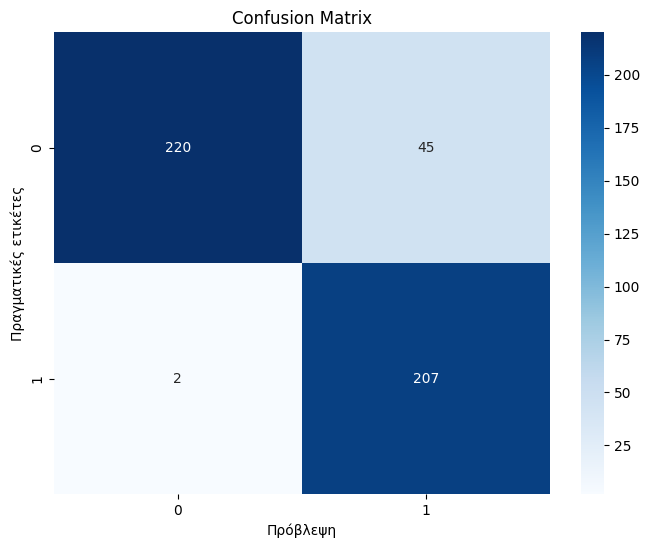

In [36]:
# Πίνακας σύγχυσης
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel('Πρόβλεψη')
plt.ylabel('Πραγματικές ετικέτες')
plt.title('Confusion Matrix')
plt.show()
print('\n')

In [37]:
mean_acc_values = []

# Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
new_test_dataset = MaskDataset(test_paths, test_labels, transform=transform)
incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=transform)
combined_test_dataset = ConcatDataset([new_test_dataset, incorrect_mask_dataset])
combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

for vv in range(5):

  # Αξιολόγηση του μοντέλου στο συνδυασμένο test set
  complex_model_augm.eval()  # Αξιολόγηση mode
  test_loss = 0.0
  correct = 0
  total = 0

  all_labels = []
  all_predictions = []

  with torch.no_grad():
      for images, labels in combined_test_loader:
          labels = labels.view(-1, 1).float()  # Αλλάξτε τη μορφή των ετικετών
          outputs = complex_model_augm(images)
          predicted = (outputs > 0.999998).float()
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
          loss = criterion(outputs, labels)
          test_loss += loss.item()
          all_labels.extend(labels.cpu().numpy())
          all_predictions.extend(predicted.cpu().numpy())

  accuracy = 100 * correct / total
  print(f'{vv}) Combined Test Loss (Label=0): {test_loss:.5f}, Combined Test Accuracy (Label=0): {accuracy:.4f}%')

  mean_acc_values.append(accuracy)

print(f'\nΜέση ακρίβεια {np.mean(mean_acc_values):.4f}%')

0) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 87.7637%
1) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 87.7637%
2) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 87.7637%
3) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 87.7637%
4) Combined Test Loss (Label=0): 5.13985, Combined Test Accuracy (Label=0): 87.7637%

Μέση ακρίβεια 87.7637%


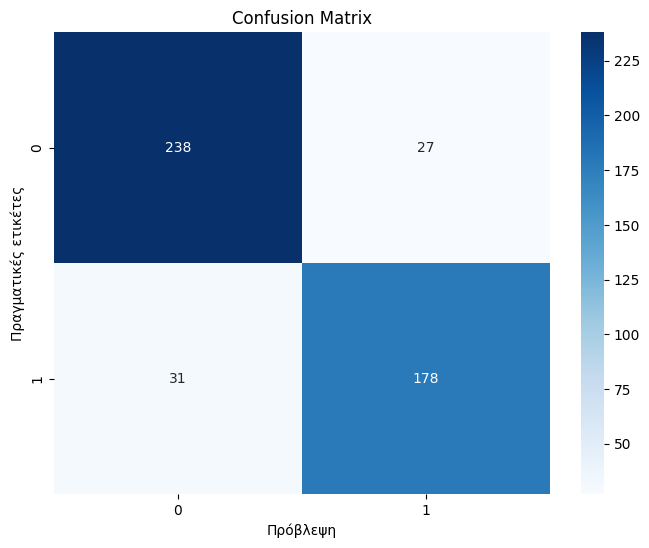

In [38]:
# Πίνακας σύγχυσης
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel('Πρόβλεψη')
plt.ylabel('Πραγματικές ετικέτες')
plt.title('Confusion Matrix')
plt.show()
print('\n')

Τελικά χαρακτηριστικά για την καλύτερη γενική λειτουργία του μοντέλου. (Για όλες τις κλάσεις)

# Ελεγχος γιατ την συμπεριφορά του τελικού δικτύου μόνο για τα δεδομένα του σετ incorrect_mask_use και για τα δεδομένα incorrect_mask_use+without_mask


Test Loss: 1.22302, Test Accuracy: 51.7857%


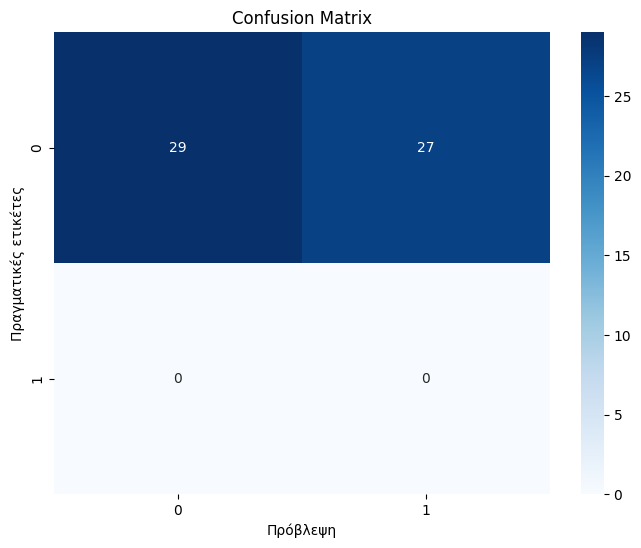

In [39]:
# Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=transform)
incorrect_mask_loader = DataLoader(incorrect_mask_dataset, batch_size=64, shuffle=False)

complex_model_augm.eval()
test_loss = 0.0
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in incorrect_mask_loader:
        labels = labels.view(-1, 1).float()  # Αλλαγή στην μορφή των ετικετών
        outputs = complex_model_augm(images)
        predicted = (outputs > 0.999998).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = 100 * correct / total
print(f'\nTest Loss: {test_loss:.5f}, Test Accuracy: {accuracy:.4f}%')

# Πίνακας σύγχυσης
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel('Πρόβλεψη')
plt.ylabel('Πραγματικές ετικέτες')
plt.title('Confusion Matrix')
plt.show()
print('\n')

Αξιολόγηση μοντέλου μόνο για τα τα δεδομένα του σετ incorrect_mask_use.

In [40]:
mean_acc_values = []

# Δημιουργία DataLoader για τις εικόνες 'mask_incorrect_use'
new_test_dataset = MaskDataset(test_paths, test_labels, transform=transform)
incorrect_mask_dataset = MaskDataset(incorrect_mask_paths, incorrect_mask_labels, transform=transform)
combined_test_dataset = ConcatDataset([new_test_dataset, incorrect_mask_dataset])
combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

for vv in range(5):

  # Αξιολόγηση του μοντέλου στο συνδυασμένο test set
  complex_model_augm.eval()  # Αξιολόγηση mode
  test_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in combined_test_loader:
          labels = labels.view(-1, 1).float()  # Αλλάξτε τη μορφή των ετικετών
          # Έλεγχος για τα δεδομένα με ετικέτα 1
          if labels[0, 0] == 0:
              outputs = complex_model_augm(images)
              predicted = (outputs > 0.999998).float()
              total += labels.size(0)
              correct += (predicted == labels).sum().item()
              loss = criterion(outputs, labels)
              test_loss += loss.item()


  accuracy = 100 * correct / total
  print(f'{vv}) Combined Test Loss (Label=0): {test_loss:.5f}, Combined Test Accuracy (Label=0): {accuracy:.4f}%')

  mean_acc_values.append(accuracy)

print(f'\nΜέση ακρίβεια {np.mean(mean_acc_values):.4f}%')

0) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.3333%
1) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.3333%
2) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.3333%
3) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.3333%
4) Combined Test Loss (Label=0): 3.63675, Combined Test Accuracy (Label=0): 83.3333%

Μέση ακρίβεια 83.3333%


Αξιολόγηση μοντέλου για τα δεδομένα του τεστ σετ με ετικέτα 0 και τα δεδομένα του σετ incorrect_mask_use.

Σημείωση: Αν δεν εφαρμόζονται τροποποιήσεις στις εικόνες δεν έχει νόημα η επαναληπτική διαδικασία, απλά δεν την αφαίρεσα εγώ. Αποφάσισα απλά να μειώσω τις επαναλήψεις σε 5. για να μην χρειάζεται μεγαλό χρόνο για την εκτέλεση.